# Optional background · GNN from scratch
This supplementary notebook explains message passing with small PyTorch examples.
It is not a prerequisite for the main YAML/CLI practical. Return to
[1 · Build a graph with Anemoi](../1_graph_neural_network.ipynb) for the actual course workflow.

# 1 · Build a graph neural network from local interactions

A value at one location is often easier to predict when we know its neighbours.
We will make that idea executable, starting with four numbers rather than a large model.

By the end you should be able to point to the **message**, **aggregation** and **update** in code,
explain a bipartite graph, and trace an encoder–processor–decoder forward pass.
Everything in this notebook is a small CPU exercise. The invented mixing rule is not an atmospheric equation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

torch.manual_seed(42)
torch.set_num_threads(4)

## 1. Specify who can send information to whom
A node has an ID and a feature value. An edge is an ordered pair `(sender, receiver)`.
For example, `(0, 1)` allows node 0 to send a message to node 1.

Our first graph has four edges: `0→1`, `2→1`, `1→2`, `3→2`.
We choose these connections; the numbers stored at the nodes can change between examples.

In [2]:
# Each row holds one node's scalar value: shape = (4 nodes, 1 feature).
values = torch.tensor([[10.0], [14.0], [20.0], [22.0]])

# Each column is one edge. Row 0 contains senders; row 1 contains receivers.
edge_index = torch.tensor([
    [0, 2, 1, 3],
    [1, 1, 2, 2],
])
sender_ids = edge_index[0]
receiver_ids = edge_index[1]

for edge_id in range(len(sender_ids)):
    sender = sender_ids[edge_id].item()
    receiver = receiver_ids[edge_id].item()
    print("Node", sender, "sends", values[sender, 0].item(), "to node", receiver)

Node 0 sends 10.0 to node 1
Node 2 sends 20.0 to node 1
Node 1 sends 14.0 to node 2
Node 3 sends 22.0 to node 2


## 2. Messages → aggregation → update
First use the sender's scalar value as the message. Sum messages at their receivers and divide
by the number of incoming edges. Thus node 1 receives `(10 + 20)/2 = 15`; node 2 receives
`(14 + 22)/2 = 18`.

The teaching implementation below visits each receiver, selects its incoming messages, and
computes their mean. A node with no incoming edges gets a zero aggregated message.
Large graph libraries implement this operation with faster scatter operations; here the explicit
loop makes each step visible.

<!-- course-illustration:message-passing -->
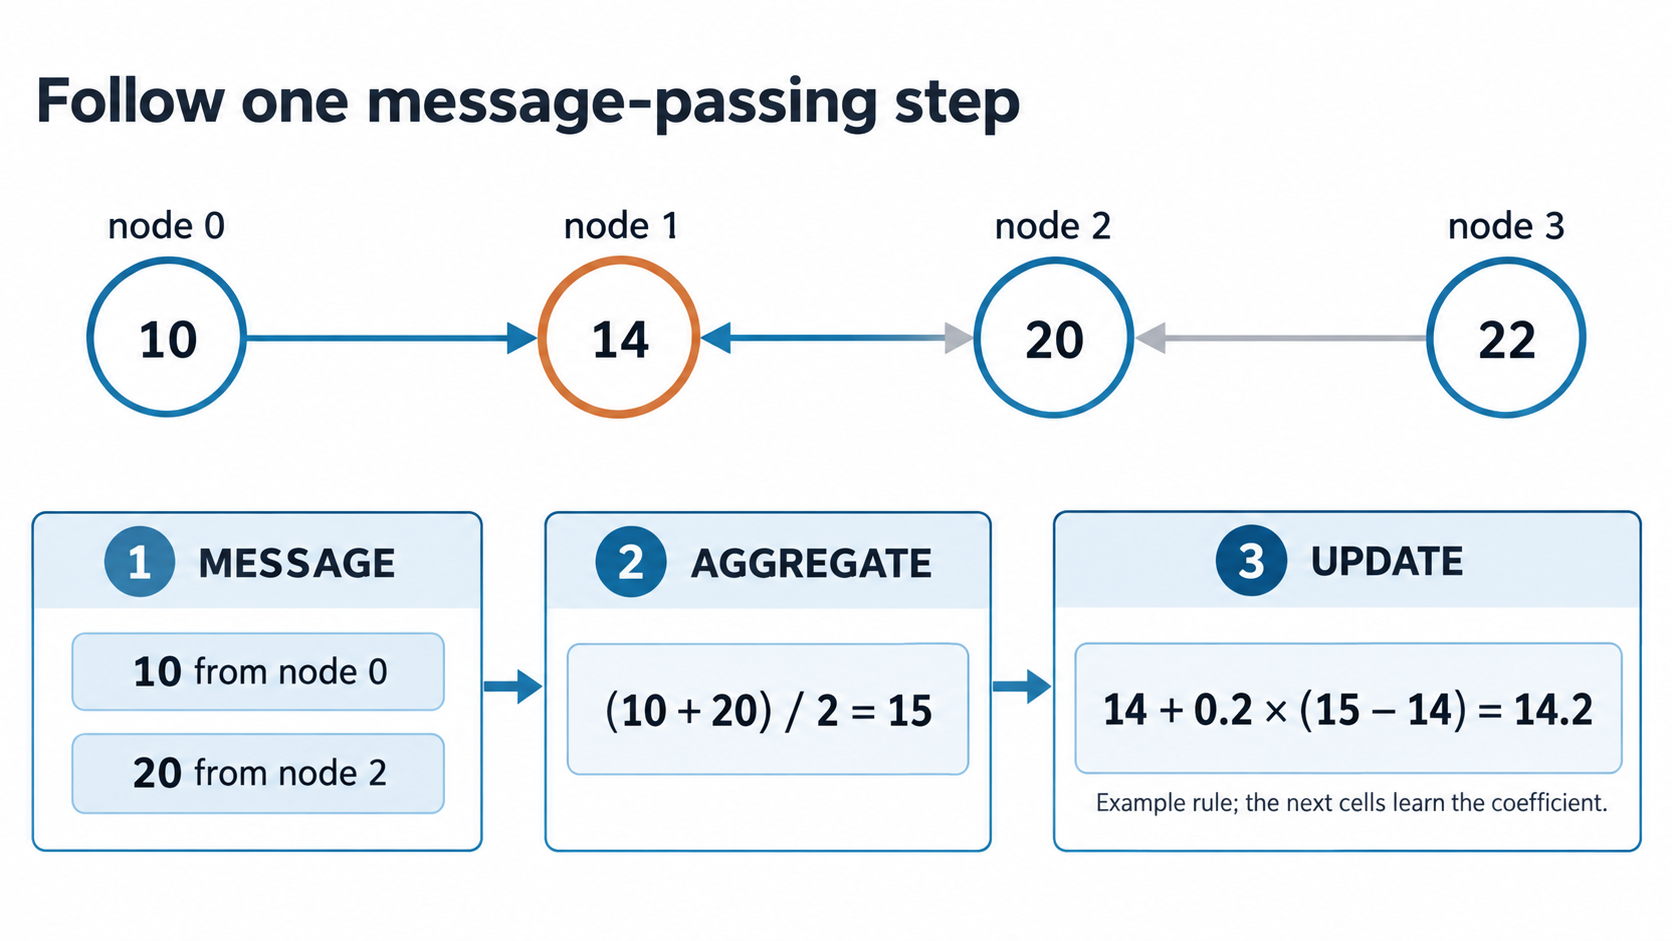

For node 1, the neighbour mean is 15. The illustrated fixed-coefficient update gives 14.2; the next experiment learns that coefficient on a ring.
<!-- /course-illustration -->

In [3]:
# Select one message per edge using the sender's node ID.
messages = values[sender_ids]

# A Boolean mask is True for edges that arrive at node 1.
arrives_at_node_1 = receiver_ids == 1
messages_for_node_1 = messages[arrives_at_node_1]
print("Messages received by node 1:", messages_for_node_1)
print("Their average:", messages_for_node_1.mean().item())

Messages received by node 1: tensor([[10.],
        [20.]])
Their average: 15.0


Now repeat the same operation for **every** receiver. In `mean(dim=0)`, `dim=0` means average
across the incoming rows, keeping one result for each feature column. The initial zeros also
give a defined result to any receiver with no incoming edges.

In [4]:
def mean_at_receivers(messages, receiver_ids, n_receivers):
    """Turn edge messages into one average per receiver."""
    n_features = messages.shape[1]
    averages = torch.zeros(
        (n_receivers, n_features), dtype=messages.dtype, device=messages.device
    )
    for node_id in range(n_receivers):
        arrives_here = receiver_ids == node_id
        incoming_messages = messages[arrives_here]
        if len(incoming_messages) > 0:
            averages[node_id] = incoming_messages.mean(dim=0)
    return averages

neighbour_mean = mean_at_receivers(messages, receiver_ids, n_receivers=4)
print("Neighbour averages:", neighbour_mean)
assert neighbour_mean[1].item() == 15
assert neighbour_mean[2].item() == 18

Neighbour averages: tensor([[ 0.],
        [15.],
        [18.],
        [ 0.]])


## 3. Turn a prescribed rule into something we can learn
Use a six-node ring so each node has two incoming neighbours. Invent this one-step rule:

$$y_i = x_i + 0.2\,\operatorname{mean}_{j\to i}(x_j-x_i).$$

The **message** is the neighbour's difference from the receiver, the **aggregation** is its
mean, and the **update** adds a fraction of that mean to the current value.
Replace the known coefficient 0.2 by a learnable parameter. This is a minimal GNN: the same
parameter is shared across all nodes and learns from errors at all of them.

In [5]:
# A six-node ring: each node receives from its left and right neighbours.
# The first six edges come from the left; the next six come from the right.
senders =   [5, 0, 1, 2, 3, 4, 1, 2, 3, 4, 5, 0]
receivers = [0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5]
ring = torch.tensor([senders, receivers])

A short guide to the PyTorch class below:

- `nn.Module` is the base class for a model; `super().__init__()` initializes it.
- `self.rate` belongs to this model. `nn.Parameter` tells PyTorch to learn that number.
- `forward` describes the prediction calculation. Calling `model(values, ring)` runs it.

The only learned number in this first model is the mixing coefficient. Each row remains one
node. Later we replace this single number with small neural networks.

In [6]:
class LocalMixingGNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rate = nn.Parameter(torch.tensor(0.0))

    def forward(self, node_values, edges):
        sender_ids = edges[0]
        receiver_ids = edges[1]
        differences = node_values[sender_ids] - node_values[receiver_ids]
        mean_difference = mean_at_receivers(differences, receiver_ids, len(node_values))
        predicted_change = self.rate * mean_difference
        return node_values + predicted_change

Make one six-node training example with a known coefficient of 0.2. One example is enough to
identify this **single shared number**; realistic weather models need many examples.
We keep the target fixed while optimizing the model, then check another example below.

In [7]:
training_values = torch.tensor([[0.0], [1.0], [3.0], [2.0], [0.0], [-1.0]])
sender_ids = ring[0]
receiver_ids = ring[1]

differences = training_values[sender_ids] - training_values[receiver_ids]
mean_difference = mean_at_receivers(differences, receiver_ids, n_receivers=6)
training_target = training_values + 0.2 * mean_difference

model = LocalMixingGNN()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [8]:
losses = []
for step in range(40):
    prediction = model(training_values, ring)        # 1. Predict.
    error = prediction - training_target
    loss = torch.mean(error ** 2)                  # 2. Measure the error.

    optimizer.zero_grad()                         # Clear previous gradients.
    loss.backward()                               # 3. Compute gradients.
    optimizer.step()                              # 4. Update the coefficient.
    losses.append(loss.item())                     # Store a Python number.

print("Learned coefficient:", model.rate.item())
print("Data-generating coefficient:", 0.2)

Learned coefficient: 0.19934667646884918
Data-generating coefficient: 0.2


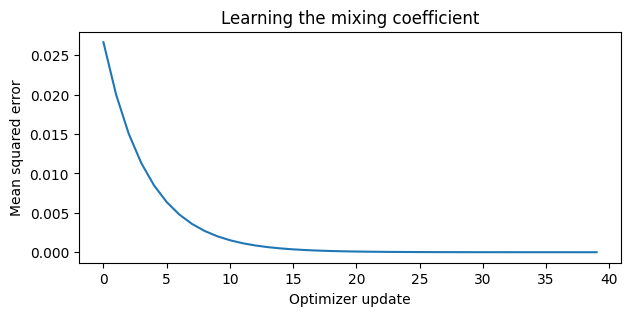

In [9]:
plt.figure(figsize=(7, 3))
plt.plot(losses)
plt.xlabel("Optimizer update")
plt.ylabel("Mean squared error")
plt.title("Learning the mixing coefficient")
plt.show()

Check a different six-node input. `torch.no_grad()` means we only want predictions; PyTorch
does not need to build the gradient calculation used during learning. `[:, 0]` selects the
first feature from every node so the plot receives one value per node.

Unseen-example MSE: 2.8458296696953767e-07


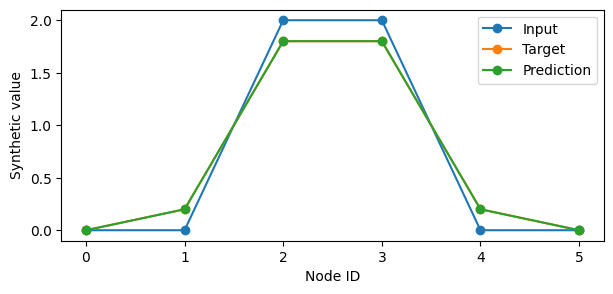

In [10]:
test_values = torch.tensor([[0.0], [0.0], [2.0], [2.0], [0.0], [0.0]])
differences = test_values[sender_ids] - test_values[receiver_ids]
mean_difference = mean_at_receivers(differences, receiver_ids, n_receivers=6)
test_target = test_values + 0.2 * mean_difference

with torch.no_grad():
    test_prediction = model(test_values, ring)
test_error = test_prediction - test_target
print("Unseen-example MSE:", torch.mean(test_error ** 2).item())

plt.figure(figsize=(7, 3))
plt.plot(test_values[:, 0], "o-", label="Input")
plt.plot(test_target[:, 0], "o-", label="Target")
plt.plot(test_prediction[:, 0], "o-", label="Prediction")
plt.xlabel("Node ID")
plt.ylabel("Synthetic value")
plt.legend()
plt.show()

**Try it:** change the data-generating coefficient and retrain. Then remove the edges into
one node. What can that node learn about its neighbours without receiving their messages?

## 4. Generalize the message and the update
For richer features, let small neural networks learn both operations:

$$m_{j\to i}=\phi([x_j,h_i]),\quad a_i=\operatorname{mean}_{j\to i}m_{j\to i},\quad h'_i=\psi([h_i,a_i]).$$

Here `[]` means concatenate features, `phi` is the message network, and `psi` is the update
network. Each network is shared across all edges or nodes. The graph decides **where** messages
travel; the learned weights decide **what** they carry.

Here `nn.Linear(a, b)` learns a weighted transformation from `a` input features to `b` output
features. `nn.Tanh()` adds a nonlinear transformation. `nn.Sequential(...)` runs those layers
in the listed order. `torch.cat(..., dim=1)` places feature columns side by side.

In [11]:
class BipartiteGNN(nn.Module):
    def __init__(self, source_features, target_features, width, output_features):
        super().__init__()
        self.message = nn.Sequential(
            nn.Linear(source_features + target_features, width),
            nn.Tanh(),
        )
        self.update = nn.Sequential(
            nn.Linear(target_features + width, width),
            nn.Tanh(),
            nn.Linear(width, output_features),
        )

    def forward(self, source_values, target_values, edges):
        sender_ids = edges[0]
        receiver_ids = edges[1]
        sender_values = source_values[sender_ids]
        receiver_values = target_values[receiver_ids]
        edge_inputs = torch.cat([sender_values, receiver_values], dim=1)
        messages = self.message(edge_inputs)
        averages = mean_at_receivers(messages, receiver_ids, len(target_values))
        update_inputs = torch.cat([target_values, averages], dim=1)
        return self.update(update_inputs)

## 5. Why “bipartite”?
A usual graph layer sends from a set of nodes back to that same set. A bipartite layer has
**two separate sets**: here six observation locations send to two latent locations.

Source ID 0 and target ID 0 refer to different nodes. The output has **two rows**, because
there are two receivers. No weather values are created just by drawing the edges; the layer
must actually compute messages and updates.

<!-- course-illustration:bipartite-map -->
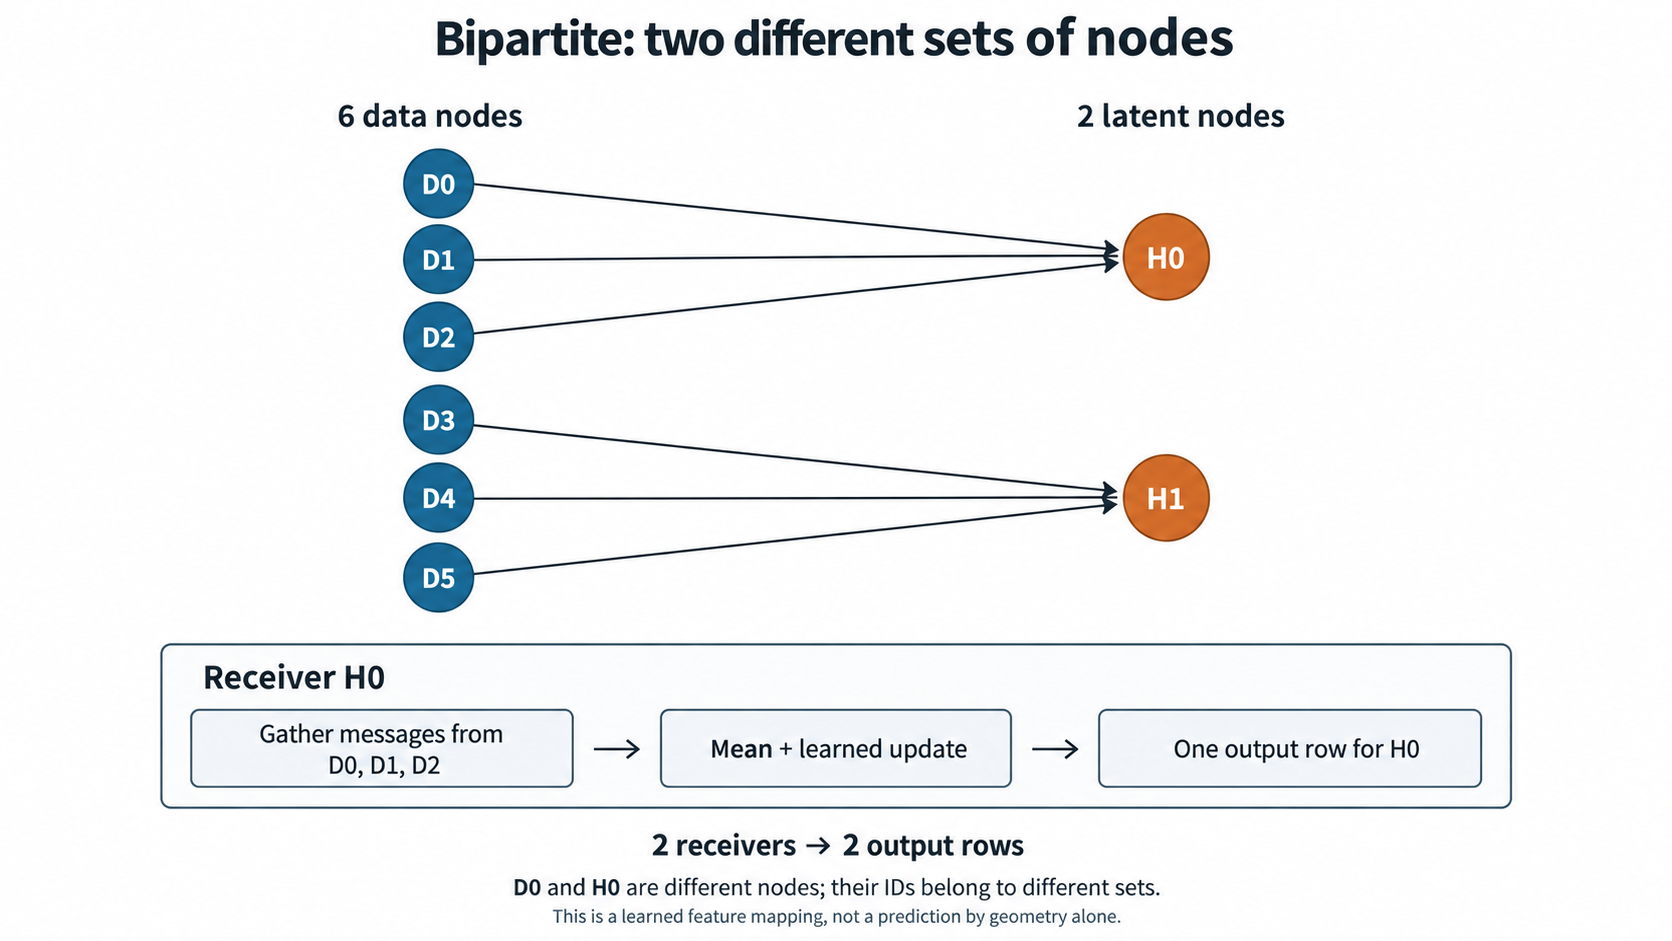

The number of receivers determines the output row count. D0 and H0 belong to separate node sets.
<!-- /course-illustration -->

In [12]:
# Each source node has two features: a value and a position.
positions = torch.linspace(0, 1, steps=6)
position_column = positions.unsqueeze(1)  # Shape (6,) becomes (6, 1).
source_values = torch.cat([test_values, position_column], dim=1)

# Each latent node starts with just its position.
latent_positions = torch.tensor([[0.2], [0.8]])
encode_edges = torch.tensor([
    [0, 1, 2, 3, 4, 5],  # Source data-node IDs.
    [0, 0, 0, 1, 1, 1],  # Receiver latent-node IDs.
])
print("Data-node features:", source_values.shape)
print("Latent-node features:", latent_positions.shape)

Data-node features: torch.Size([6, 2])
Latent-node features: torch.Size([2, 1])


In [13]:
encoder = BipartiteGNN(
    source_features=2, target_features=1, width=8, output_features=8
)
latent_features = encoder(source_values, latent_positions, encode_edges)
print("Encoded features:", latent_features.shape)  # 2 receivers, 8 features each.

Encoded features: torch.Size([2, 8])


## 6. Construct a complete forward pass
The encoder changes the representation from data nodes to latent nodes. The processor
exchanges information among latent nodes. The decoder sends the processed information back
to the data nodes. A final residual addition turns a predicted change into a predicted state.

```text
current data → Encoder → latent features → Processor → Decoder → predicted change
      └────────────────────────────────────────────────────── + → next state
```

This tiny untrained example makes the wiring visible. The next notebook uses Anemoi's
larger implementation, two input times and multiple weather variables.

In [14]:
processor = BipartiteGNN(
    source_features=8, target_features=8, width=8, output_features=8
)
latent_edges = torch.tensor([[0, 1, 0, 1], [0, 0, 1, 1]])
latent_change = processor(latent_features, latent_features, latent_edges)
processed_features = latent_features + latent_change

# Reverse encoder connections: latent nodes now send to data nodes.
decode_edges = torch.stack([encode_edges[1], encode_edges[0]])
decoder = BipartiteGNN(
    source_features=8, target_features=2, width=8, output_features=1
)
predicted_change = decoder(processed_features, source_values, decode_edges)
next_state = test_values + predicted_change

print("Processed latent features:", processed_features.shape)
print("Predicted change:", predicted_change.shape)
print("Next state:", next_state.shape)

Processed latent features: torch.Size([2, 8])
Predicted change: torch.Size([6, 1])
Next state: torch.Size([6, 1])


## 7. Where does attention fit?
A mean treats all incoming messages equally. Attention computes weights from the current
receiver (**query**) and each sender (**key**), then combines sender **values**:

$$\alpha_{ij}=\mathrm{softmax}_{j\to i}(q_i^\top k_j/\sqrt d),\quad a_i=\sum_{j\to i}\alpha_{ij}v_j.$$

Softmax is taken over the allowed senders for **that receiver**. In a trained model, linear
layers learn how to form queries, keys and values. Here we choose them explicitly so you can
check the calculation. Multi-head attention repeats it with different learned projections.
A transformer block adds feature transformations, normalization and residual connections.

Weights: tensor([0.5760, 0.2840, 0.1400])
Weight sum: 1.0
Equal-weight average: 20.0
Attention result: 15.640539169311523


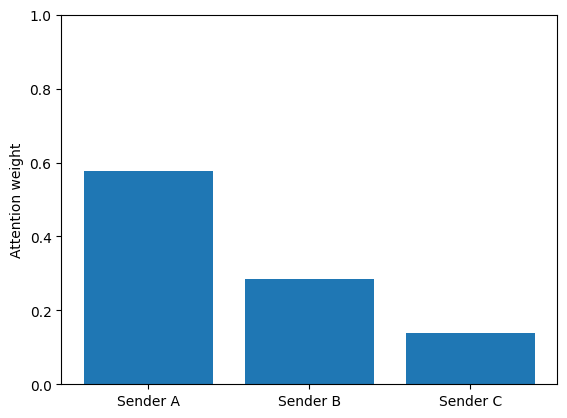

In [15]:
query = torch.tensor([1.0, 0.0])
keys = torch.tensor([[1.0, 0.0], [0.0, 1.0], [-1.0, 0.0]])
sent_values = torch.tensor([10.0, 20.0, 30.0])

# Compare this receiver's query with each sender's key.
scores = torch.matmul(keys, query)
scaled_scores = scores / np.sqrt(2)  # Two features in each query/key.
weights = torch.softmax(scaled_scores, dim=0)
weighted_values = weights * sent_values
attention_result = weighted_values.sum()

print("Weights:", weights)
print("Weight sum:", weights.sum().item())
print("Equal-weight average:", sent_values.mean().item())
print("Attention result:", attention_result.item())

plt.bar(["Sender A", "Sender B", "Sender C"], weights.numpy())
plt.ylabel("Attention weight")
plt.ylim(0, 1)
plt.show()

## Connect this to the forecast model
Notebook 2 uses graph-attention mappings for the encoder and decoder, and transformer
processing on an O32 latent grid. It follows the same data → latent → data construction.
The code above is our small explanatory model, not a replacement implementation of those library layers.

Before moving on, explain: What fixes the output row count? Which operation groups messages?
What changes when we replace a mean by attention? Why can several students use the same model
architecture while training different weights?

These course explanations, numerical examples and plots were written for this course.
Software: [PyTorch](https://pytorch.org/), [Anemoi](https://github.com/ecmwf/anemoi-core)
and their contributors. Meteorological examples use the prepared ERA5 dataset.
The small forecasting exercise is a teaching model, not the operational AIFS system.